
### Për ta bërë procesin më të lehtë, ndrysho rrugët (paths) dhe vendosi të dhënat e tua në të njëjtat dosje (fshi të dhënat e tua të mëparshme - Dt).


In [2]:
from data import *



# Zgjerimi i të dhënave (Data augmentatio)

Në detyrat e mësimt të thellë (deep learning), nevojiten shumë të dhëna për të trajnuar një model DNN. Kur dataset-i nuk është mjaftueshëm i madh, duhet të përdoret zgjerimi i të dhënave (data augmentation).

`keras.preprocessing.image.ImageDataGenerator` është një gjenerues të dhënash, i cili mund të furnizojë modelin DNN me të dhëna në formën (data, etiketë), dhe në të njëjtën kohë mund të bëjë zgjerimin e të dhënave.

Është shumë i përshtatshëm për ne që të përdorim `ImageDataGenerator` nga Keras për të zbatuar rotacion, zhvendosje, shkallëzim dhe transformime të tjera të imazheve... për më shumë detaje shiko [dokumentacionin e keras](https://keras.io/preprocessing/image/).

Për detyra të segmentimit të imazheve, **imazhi dhe maska duhet të transformohen së bashku!!**


## përcakto gjeneruesin tënd të të dhënave (ne baze te te dhenave)

Nëse dëshiron të vizualizosh rezultatin e zgjerimit të të dhënave, vendos `save_to_dir = rruga_juaj`


In [3]:
# Nëse nuk dëshiron të bësh zgjerimin e të dhënave, vendos `data_gen_args` si një fjalor bosh.
# data_gen_args = dict()


data_gen_args = dict(rotation_range=0.2,
                    width_shift_range=0.05,
                    height_shift_range=0.05,
                    shear_range=0.05,
                    zoom_range=0.05,
                    horizontal_flip=True,
                    fill_mode='nearest')
myGenerator = trainGenerator(20,'data/membrane/train','image','label',data_gen_args,save_to_dir = "data/membrane/train/aug")

## vizualizojm rezultatin e zgjerimit të të dhënave


In [4]:
# Do të shikoni 60 imazhe të transformuara dhe maskat e tyre në data/membrane/train/aug
num_batch = 3
for i, batch in enumerate(myGenerator):
    if(i >= num_batch):
        break


Found 30 images belonging to 1 classes.
Found 30 images belonging to 1 classes.


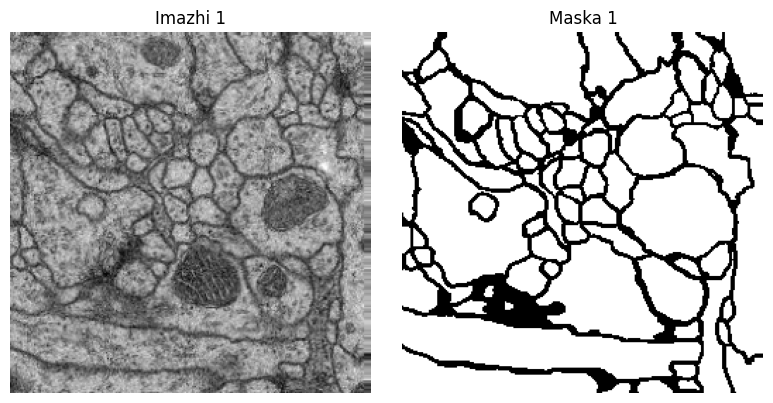

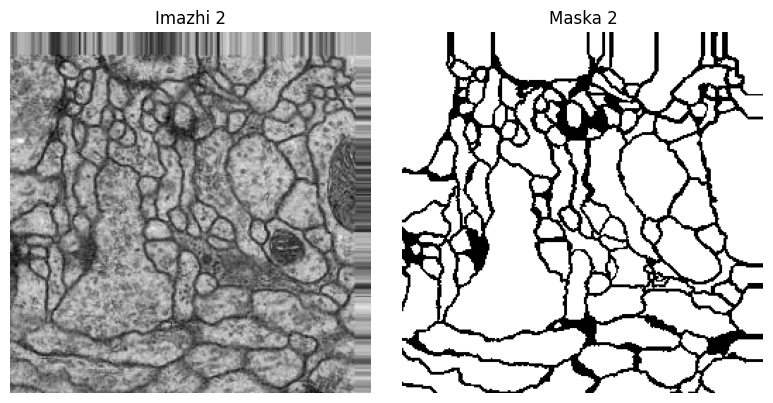

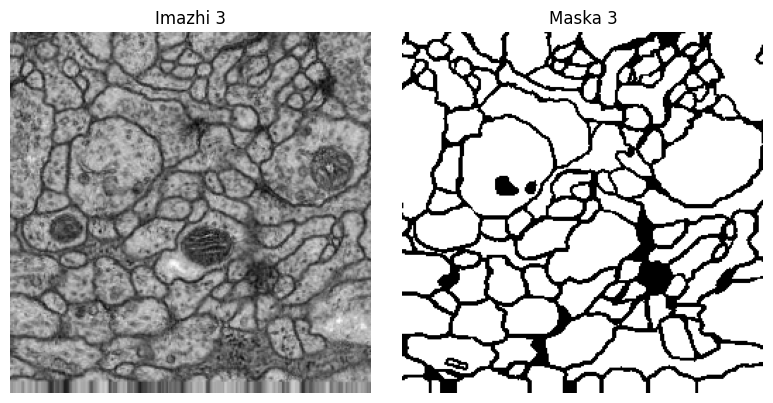

In [5]:
import matplotlib.pyplot as plt

# Merr një batch nga gjeneratori
images, masks = next(myGenerator)

# Shfaq 3 imazhe dhe maskat përkatëse
for i in range(3):
    plt.figure(figsize=(8, 4))

    # Imazhi origjinal
    plt.subplot(1, 2, 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f'Imazhi {i+1}')
    plt.axis('off')

    # Maska përkatëse
    plt.subplot(1, 2, 2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title(f'Maska {i+1}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


## krijo të dhëna .npy

Nëse kompjuteri yt ka mjaftueshëm memorie, mund të krijosh skedarë .npy që përmbajnë të gjitha imazhet dhe maskat, dhe t’ia japësh si hyrje modelit DNN.


In [6]:
image_arr,mask_arr = geneTrainNpy("data/membrane/train/aug/","data/membrane/train/aug/")
#np.save("data/image_arr.npy",image_arr)
#np.save("data/mask_arr.npy",mask_arr)

In [7]:
image_arr.shape

(140, 256, 256, 1)

In [8]:
mask_arr.shape

(140, 256, 256, 1)